In [ ]:
s!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "sumaiyabinteshahid/isic-challenge-dataset-2020"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'isic-challenge-dataset-2020' dataset.
Dataset path: /kaggle/input/isic-challenge-dataset-2020


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
import os
import pandas as pd

train_df = pd.read_csv(os.path.join(path, "ISIC_2020_Dataset", "ISIC_2020_Train_Metadata.csv"))

train_df.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0


In [ ]:
train_df.shape

(33126, 9)

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33126 entries, 0 to 33125
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     33126 non-null  object 
 1   patient_id                     33126 non-null  object 
 2   lesion_id                      33126 non-null  object 
 3   sex                            33061 non-null  object 
 4   age_approx                     33058 non-null  float64
 5   anatom_site_general_challenge  32599 non-null  object 
 6   diagnosis                      33126 non-null  object 
 7   benign_malignant               33126 non-null  object 
 8   target                         33126 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 2.3+ MB


In [ ]:
train_df.isnull().sum()

,0
image_name,0
patient_id,0
lesion_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [ ]:
train_df.dropna()


,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,IL_7972535,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,IL_4649854,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,IL_9087444,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,IL_4255399,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,IL_6898037,female,55.0,upper extremity,unknown,benign,0
...,...,...,...,...,...,...,...,...,...
33121,ISIC_9999134,IP_6526534,IL_2076932,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,IL_6891604,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,IL_6364820,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,IL_6048457,male,50.0,lower extremity,unknown,benign,0


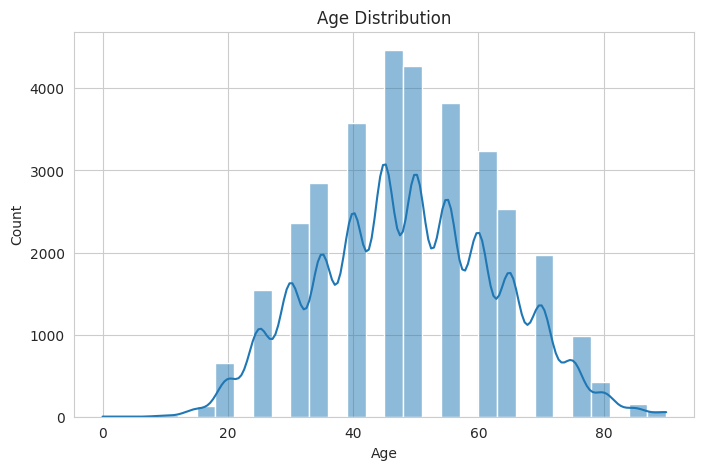

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["age_approx"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

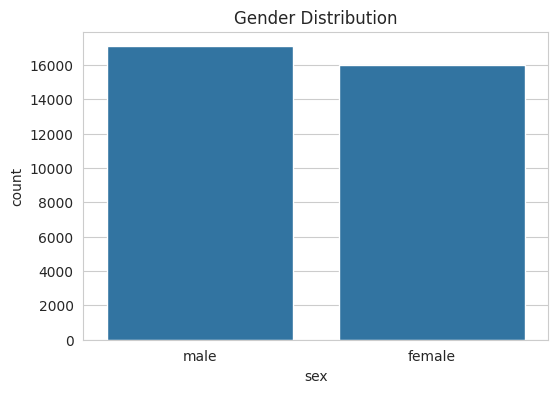

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=train_df)
plt.title("Gender Distribution")
plt.show()

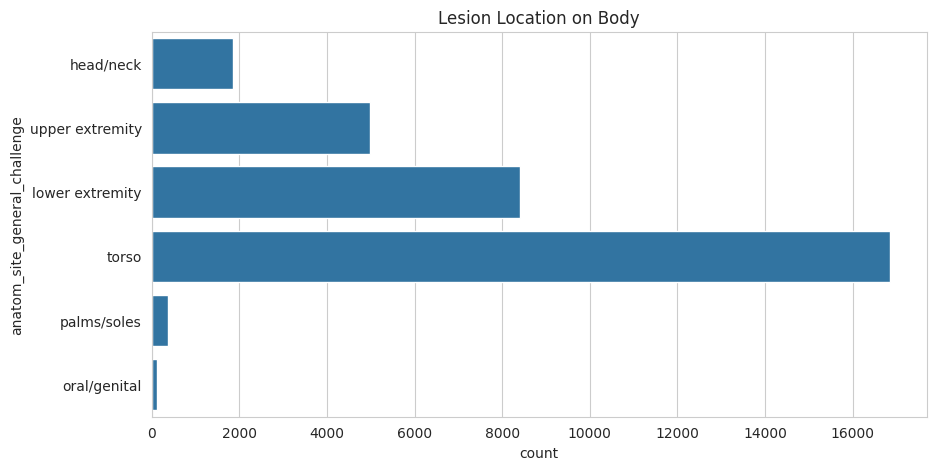

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y="anatom_site_general_challenge", data=train_df)
plt.title("Lesion Location on Body")
plt.show()

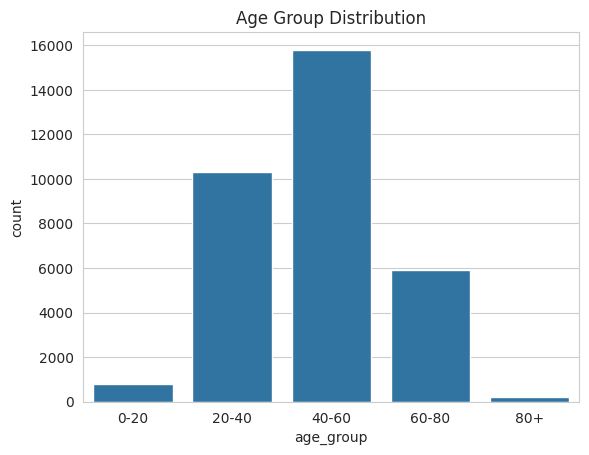

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_df["age_group"] = pd.cut(
    train_df["age_approx"],
    bins=[0,20,40,60,80,100],
    labels=["0-20","20-40","40-60","60-80","80+"]
)

sns.countplot(x="age_group", data=train_df)
plt.title("Age Group Distribution")
plt.show()

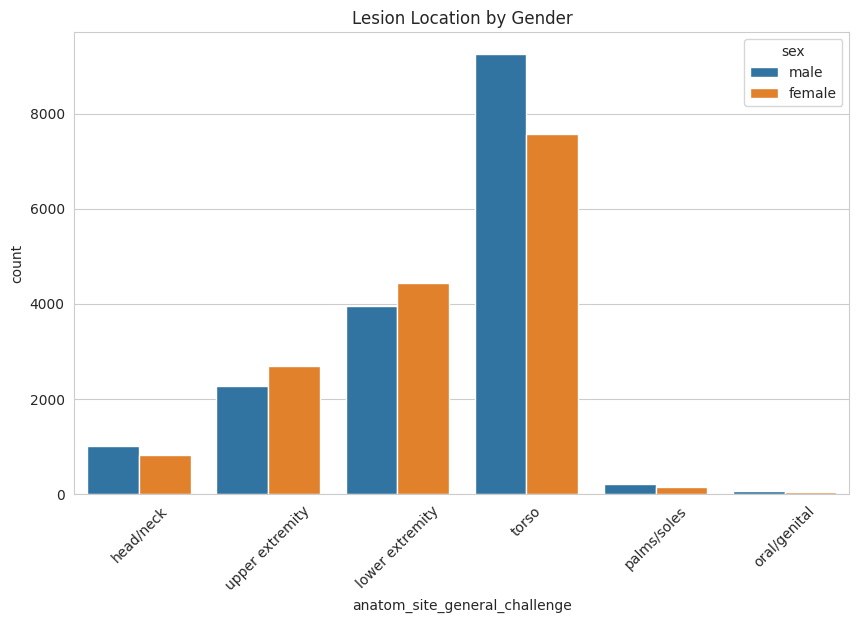

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="anatom_site_general_challenge", hue="sex", data=train_df)
plt.xticks(rotation=45)
plt.title("Lesion Location by Gender")
plt.show()

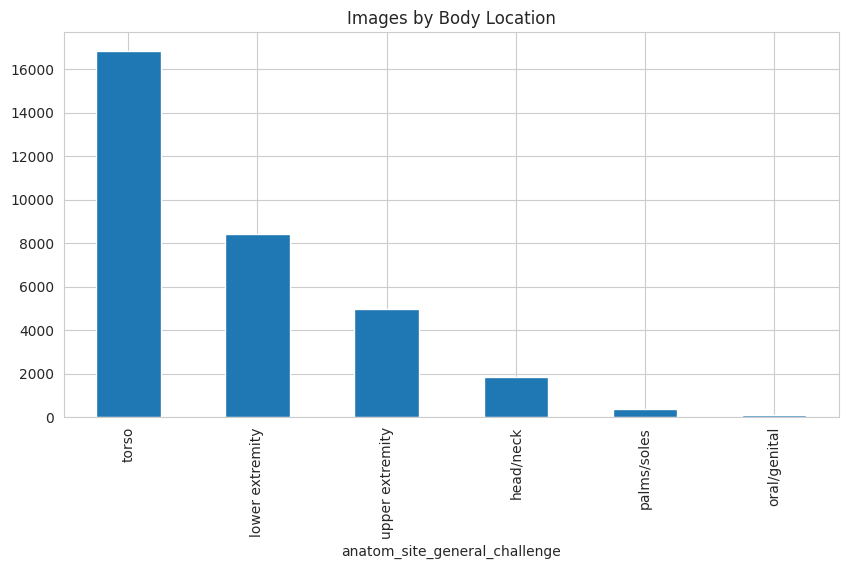

In [ ]:
train_df["anatom_site_general_challenge"].value_counts().plot(
    kind="bar", figsize=(10,5)
)

plt.title("Images by Body Location")
plt.show()

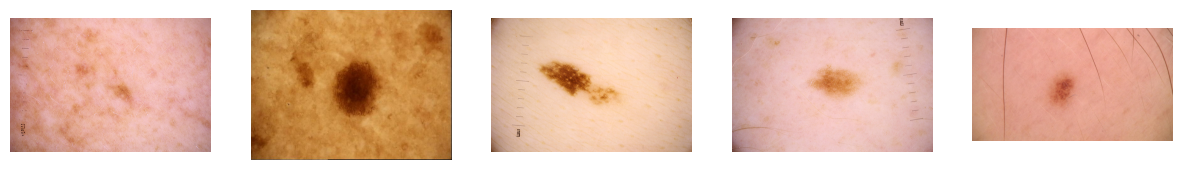

In [ ]:
import os
from PIL import Image

img_path = os.path.join(path, "ISIC_2020_Dataset", "train") + os.sep

sample = train_df.sample(5)

plt.figure(figsize=(15,5))

for i, img in enumerate(sample["image_name"]):
    plt.subplot(1,5,i+1)
    image = Image.open(img_path + img + ".jpg")
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [ ]:
print("Total Images:", len(train_df))
print("Unique Patients:", train_df["patient_id"].nunique())
print("Gender Distribution:")
print(train_df["sex"].value_counts())

Total Images: 33126
Unique Patients: 2056
Gender Distribution:
sex
male      17080
female    15981
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Changed 'age_approx' to 'age_group' as it's already a categorical representation
cols = ["sex", "age_group", "anatom_site_general_challenge"]

# Add 'unknown' to the categories of the 'age_group' and 'anatom_site_general_challenge' columns
# This is necessary because fillna('unknown') will attempt to add a new category if 'unknown' isn't present.
# For 'sex', the handle_unknown='ignore' in OneHotEncoder will manage it.
for col in ["age_group", "anatom_site_general_challenge", "sex"]:
    # Updated to use isinstance(dtype, pd.CategoricalDtype) as suggested by DeprecationWarning
    if isinstance(train_df[col].dtype, pd.CategoricalDtype):
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")
    # Convert object columns to categorical if not already, to ensure add_categories works
    elif train_df[col].dtype == 'object':
        train_df[col] = train_df[col].astype('category')
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")

encoder = OneHotEncoder(handle_unknown="ignore")

encoded = encoder.fit_transform(
    train_df[cols].fillna("unknown")
).toarray()

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols))

train_df = pd.concat([train_df, encoded_df], axis=1)

meta_features = encoded_df.columns.tolist()

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Drop rows with NaN in 'image_name' and 'target' BEFORE splitting
# This addresses both the 'Input y contains NaN' for stratification
# and the 'nan.jpg' FileNotFoundError.
train_df.dropna(subset=['image_name', 'target'], inplace=True)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["target"],
    random_state=42
)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch
import numpy as np

class MelanomaDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Corrected image path to include 'ISIC_2020_Dataset/train'
        # Ensure image_name is a string before concatenation
        img_name = str(row.image_name)
        img_path = os.path.join(
            path,
            "ISIC_2020_Dataset",
            "train",
            img_name + ".jpg"
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta_values = row[meta_features].values.astype(np.float32)
        meta = torch.tensor(meta_values)

        label = torch.tensor(row.target).float()

        return image, meta, label

In [ ]:
train_dataset = MelanomaDataset(train_df, transform)
val_dataset = MelanomaDataset(val_df, transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
import torch.nn as nn
import torchvision

class MelanomaModel(nn.Module):

    def __init__(self, meta_features):

        super().__init__()

        resnet = torchvision.models.resnet101(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = False

        self.image_encoder = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_features,100),
            nn.ReLU(),
            nn.Linear(100,3),
            nn.ReLU()
        )

        self.classifier = nn.Linear(2048 + 3, 1)

    def forward(self, image, meta):

        x = self.image_encoder(image)
        x = x.view(x.size(0), -1)

        m = self.meta_encoder(meta)

        z = torch.cat([x,m], dim=1)

        return self.classifier(z)

In [ ]:
import torch
import torch.nn as nn
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MelanomaModel(nn.Module):

    def __init__(self, meta_features_len):

        super().__init__()

        resnet = torchvision.models.resnet101(pretrained=True)

        for param in resnet.parameters():
            param.requires_grad = False

        self.image_encoder = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.meta_encoder = nn.Sequential(
            nn.Linear(meta_features_len,100),
            nn.ReLU(),
            nn.Linear(100,3),
            nn.ReLU()
        )

        self.classifier = nn.Linear(2048 + 3, 1)

    def forward(self, image, meta):

        x = self.image_encoder(image)
        x = x.view(x.size(0), -1)

        m = self.meta_encoder(meta)

        z = torch.cat([x,m], dim=1)

        return self.classifier(z)

model = MelanomaModel(len(meta_features)).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 281MB/s]


In [ ]:
import torch.nn as nn
import torch.optim

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
!pip install fastprogress

In [ ]:
import numpy as np
import torch
from fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score

In [ ]:
def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())

In [ ]:
from torch.utils.data import DataLoader

dataloader = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,   # important
        shuffle=True
    ),

    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )
}

In [ ]:
batch_size = 1

In [ ]:
imgs, meta, labels = next(iter(dataloader['train']))

print(imgs.shape)
print(meta.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 16])


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Changed 'age_approx' to 'age_group' as it's already a categorical representation
cols = ["sex", "age_group", "anatom_site_general_challenge"]

# Add 'unknown' to the categories of the 'age_group' and 'anatom_site_general_challenge' columns
# This is necessary because fillna('unknown') will attempt to add a new category if 'unknown' isn't present.
# For 'sex', the handle_unknown='ignore' in OneHotEncoder will manage it.
for col in ["age_group", "anatom_site_general_challenge", "sex"]:
    # Updated to use isinstance(dtype, pd.CategoricalDtype) as suggested by DeprecationWarning
    if isinstance(train_df[col].dtype, pd.CategoricalDtype):
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")
    # Convert object columns to categorical if not already, to ensure add_categories works
    elif train_df[col].dtype == 'object':
        train_df[col] = train_df[col].astype('category')
        if "unknown" not in train_df[col].cat.categories:
            train_df[col] = train_df[col].cat.add_categories("unknown")

encoder = OneHotEncoder(handle_unknown="ignore")

encoded = encoder.fit_transform(
    train_df[cols].fillna("unknown")
).toarray()

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols))

train_df = pd.concat([train_df, encoded_df], axis=1)

meta_features = encoded_df.columns.tolist()

print("Number of metadata features:", len(meta_features))

Number of metadata features: 16


In [ ]:
class MelanomaDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Ensure image_name is a string and correct the image path
        img_name = str(row.image_name)
        img_path = os.path.join(
            path,
            "ISIC_2020_Dataset",
            "train",
            img_name + ".jpg"
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(
            row[meta_features].values.astype(np.float32)
        )

        label = torch.tensor(row.target).float()

        return image, meta, label

In [ ]:
train_dataset = MelanomaDataset(train_df, transform)
val_dataset = MelanomaDataset(val_df, transform)

dataloader = {
    "train": DataLoader(train_dataset, batch_size=32, shuffle=True),
    "val": DataLoader(val_dataset, batch_size=32, shuffle=False)
}

In [ ]:
# Check for literal 'nan' string in image_name in train_df and val_df
print("Count of 'nan' string in train_df['image_name']:", (train_df['image_name'] == 'nan').sum())
print("Count of 'nan' string in val_df['image_name']:", (val_df['image_name'] == 'nan').sum())

# Also check for actual np.nan values just in case, though initial check showed 0
print("Count of np.nan in train_df['image_name']:", train_df['image_name'].isnull().sum())
print("Count of np.nan in val_df['image_name']:", val_df['image_name'].isnull().sum())

Count of 'nan' string in train_df['image_name']: 0
Count of 'nan' string in val_df['image_name']: 0
Count of np.nan in train_df['image_name']: 5239
Count of np.nan in val_df['image_name']: 0


In [ ]:
import numpy as np
import torch
from fastprogress.fastprogress import master_bar, progress_bar
from sklearn.metrics import roc_auc_score

def AUC(outputs, targets):
    outputs = torch.sigmoid(outputs)
    return roc_auc_score(targets.numpy(), outputs.numpy())

model = MelanomaModel(len(meta_features)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

epochs = 1
validation_steps = 15

mb = master_bar(range(1, epochs+1))
best_auc = 0

model.to(device)

for epoch in mb:

    # ---------- TRAIN ----------
    train_loss = []
    model.train()

    for imgs, meta, labels in progress_bar(train_loader, parent=mb):

        imgs = imgs.to(device)
        meta = meta.to(device)

        # fix label shape
        labels = labels.unsqueeze(1).to(device)

        outputs = model(imgs, meta)

        optimizer.zero_grad()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss.append(loss.item())

        mb.child.comment = f'loss: {np.mean(train_loss):.5f}'


    # ---------- VALIDATION ----------
    val_loss = []
    model.eval()

    validation_step = 0

    val_outputs = torch.tensor([])
    val_targets = torch.tensor([])

    with torch.no_grad():

        for imgs, meta, labels in progress_bar(val_loader, parent=mb):

            imgs = imgs.to(device)
            meta = meta.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(imgs, meta)

            loss = criterion(outputs, labels)

            val_loss.append(loss.item())

            mb.child.comment = f'val_loss: {np.mean(val_loss):.5f}'

            val_outputs = torch.cat([val_outputs, outputs.cpu()])
            val_targets = torch.cat([val_targets, labels.cpu()])

            validation_step += 1

            if validation_step > validation_steps:
                break


    # ---------- AUC ----------
    auc = AUC(val_outputs, val_targets)


    # ---------- SAVE BEST MODEL ----------
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "model.pth")


    # ---------- PRINT RESULT ----------
    mb.write(
        f'epoch: {epoch} | train_loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | auc_loss: {auc:.5f}'
    )

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<div><p>epoch: 1 | train_loss: 0.14833 | val_loss: 0.11498 | auc_loss: 0.78983</p></div>

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    val_targets.numpy(),
    torch.sigmoid(val_outputs).numpy()
)

print("Final Validation AUC:", auc)

Final Validation AUC: 0.7898333333333334


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# convert probabilities to binary predictions
probs = torch.sigmoid(val_outputs).numpy()
preds = (probs > 0.07).astype(int)

targets = val_targets.numpy()

# metrics
accuracy = accuracy_score(targets, preds)
f1 = f1_score(targets, preds)
precision = precision_score(targets, preds)
sensitivity = recall_score(targets, preds)  # same as recall

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")

Accuracy: 0.9297
F1 Score: 0.2174
Precision: 0.1471
Sensitivity (Recall): 0.4167


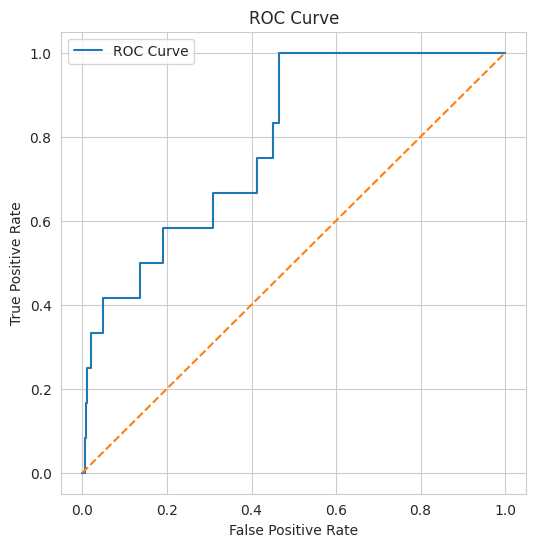

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    val_targets.numpy(),
    torch.sigmoid(val_outputs).numpy()
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

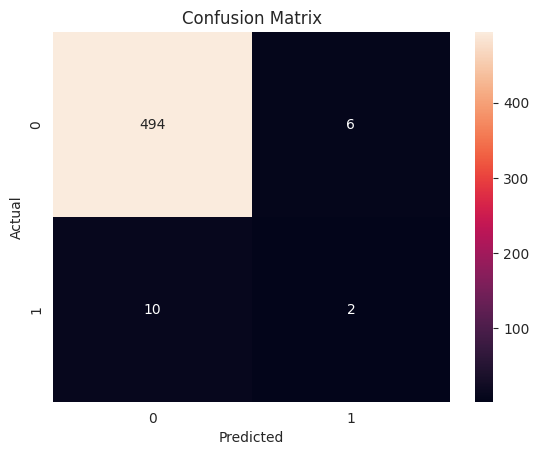

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds = (torch.sigmoid(val_outputs) > 0.3).int()

cm = confusion_matrix(
    val_targets.numpy(),
    preds.numpy()
)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()